# GTEx Embedding Diagnostics - No ComBat Covariates


## Table of Contents

1. Notebook configuration
2. Shared PREPOST reconstruction
3. Embedding matrices
4. PCA
5. UMAP
6. Coloring controls
7. Gene-wise embeddings
    - Gene-wise PCA
    - Gene-wise UMAP


In [11]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt

import src.eval_utils.eval_embeddings as eval_embeddings
importlib.reload(eval_embeddings)
from src.eval_utils.eda_core import EDAConfig, prepare_pre_post_harmonization_cached
from src.eval_utils.eval_embeddings import (
    add_gtex_native_region_labels,
    build_gene_embedding_matrix,
    build_prepost_region_embedding_matrix,
    build_region_embedding_matrix_from_tensor_view,
    compute_pca_embedding,
    compute_umap_embedding,
    plot_embedding_sequence,
)
from src.eval_utils.eval_samples import MatchingContext, build_prediction_tensor_view
from src.eval_utils.eval_style import set_academic_style

set_academic_style()


## Notebook Configuration

In [12]:
# === Global config ===
CSV_PATH = "data/raw/gxp_samples.csv"
CACHE_ROOT = 'out/loro_subject_cache_cv_nocov'
GENE_SCOPE = "allgenes"
MIN_OBSERVED_PARCELS = 5
COMBAT_USE_COVARIATES = False
DROP_MACRO_SYSTEM_COVARIATE = False

# center | standardize | none
FEATURE_PREPROCESS = "center"

# region | gtex_native_region | macro_system | region_group | age | sex | dataset
COLOR_BY = "gtex_native_region"
POINT_SIZE = 8

LORO_MODEL = "dlam"
REGION_ORDERING = "region_matched"  # target_parcel | region_matched | region_matched_superset
ACTIVE_GENE_LIST = None
N_PCA_FOR_UMAP = 20
RANDOM_STATE = 0
MAX_LEGEND_ITEMS = 40

## Shared PREPOST Reconstruction

In [13]:
CFG = EDAConfig(
    csv_path=CSV_PATH,
    cache_root=CACHE_ROOT,
    gene_scope=GENE_SCOPE,
    min_observed_parcels=MIN_OBSERVED_PARCELS,
    combat_use_covariates=COMBAT_USE_COVARIATES,
    drop_macro_system_covariate=DROP_MACRO_SYSTEM_COVARIATE,
)
PREPOST = prepare_pre_post_harmonization_cached(CFG, verbose=True)

print('subjects:', len(PREPOST['subjects']))
print('genes:   ', len(PREPOST['genes']))
print('parcels: ', PREPOST['raw_cube'].shape[1])
print('raw_cube:', PREPOST['raw_cube'].shape)
print('harm_cube:', PREPOST['harm_cube'].shape)


[prepost_cache] hit  notebooks/cache/prepost/2ff33705d04ea284.pkl  (8961.2 MB)
subjects: 318
genes:    11704
parcels:  150
raw_cube: (318, 150, 11704)
harm_cube: (318, 150, 11704)


## Embedding Matrices

In [14]:
# PREPOST is the direct source for ground-truth and post-ComBat truth.
ground_truth_matrix = build_prepost_region_embedding_matrix(
    PREPOST,
    dataset="GTEx",
    stage="raw_matched",
)
combat_matrix = build_prepost_region_embedding_matrix(
    PREPOST,
    dataset="GTEx",
    stage="harmonized",
)

# TensorView is useful once the stage comes from the subject-level prediction cache.
CTX = MatchingContext.from_cfg(CFG, PREPOST)
loro_recon_view = build_prediction_tensor_view(
    CACHE_ROOT,
    LORO_MODEL,
    dataset="GTEx",
    stage="loro_recon",
    cfg=CFG,
    prepost=PREPOST,
    matching_context=CTX,
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    random_seed=RANDOM_STATE,
)
loro_recon_matrix = build_region_embedding_matrix_from_tensor_view(loro_recon_view)

# Enables COLOR_BY="gtex_native_region" for all stages, including cache-derived LORO rows.
ground_truth_matrix = add_gtex_native_region_labels(ground_truth_matrix, PREPOST)
combat_matrix = add_gtex_native_region_labels(combat_matrix, PREPOST)
loro_recon_matrix = add_gtex_native_region_labels(loro_recon_matrix, PREPOST)

MATRICES = [ground_truth_matrix, combat_matrix, loro_recon_matrix]
STAGE_TITLES = ["GTEx ground truth", "GTEx post-ComBat", f"{LORO_MODEL.upper()} LORO recon"]

for title, mat in zip(STAGE_TITLES, MATRICES):
    print(f"{title}: {mat.X.shape[0]:,} samples x {mat.X.shape[1]:,} genes; dropped rows={mat.dropped_rows}; source={mat.dataset}/{mat.stage}")

ground_truth_matrix.metadata.head()


GTEx ground truth: 2,869 samples x 11,704 genes; dropped rows=0; source=GTEx/raw_matched
GTEx post-ComBat: 2,869 samples x 11,704 genes; dropped rows=0; source=GTEx/harmonized
DLAM LORO recon: 2,869 samples x 11,704 genes; dropped rows=0; source=GTEx/loro_recon


,dataset,subject,subject_index,parcel_idx,region_index,stage,pipeline_stage,region_axis_kind,future_imputation,tissue_or_parcel,...,hemisphere,coord_x,coord_y,coord_z,region,region_group,gtex_native_regions,gtex_native_region,age,sex
0,GTEx,GTEX-1117F,0,4,4,raw_matched,raw_matched,target_parcel,False,Cerebellar_Region4,...,M,-26.042061,-53.603575,-51.260778,Cerebellar_Region4,cerebellar,brain - cerebellar hemisphere,brain - cerebellar hemisphere,64.0,F
1,GTEx,GTEX-1117F,0,10,10,raw_matched,raw_matched,target_parcel,False,LH-Ca,...,L,-13.714286,6.556258,8.983565,LH-Ca,subcortical,brain - caudate (basal ganglia),brain - caudate (basal ganglia),64.0,F
2,GTEx,GTEX-1117F,0,18,18,raw_matched,raw_matched,target_parcel,False,LH-NAC,...,L,-9.566667,7.900000,-9.533333,LH-NAC,subcortical,brain - nucleus accumbens (basal ganglia),brain - nucleus accumbens (basal ganglia),64.0,F
3,GTEx,GTEX-1117F,0,19,19,raw_matched,raw_matched,target_parcel,False,LH-Pu,...,L,-25.115813,0.356347,0.599109,LH-Pu,subcortical,brain - putamen (basal ganglia),brain - putamen (basal ganglia),64.0,F
4,GTEx,GTEX-1117F,0,23,23,raw_matched,raw_matched,target_parcel,False,LH-SNr,...,L,-9.565217,-16.521739,-12.826087,LH-SNr,subcortical,brain - substantia nigra,brain - substantia nigra,64.0,F


## PCA

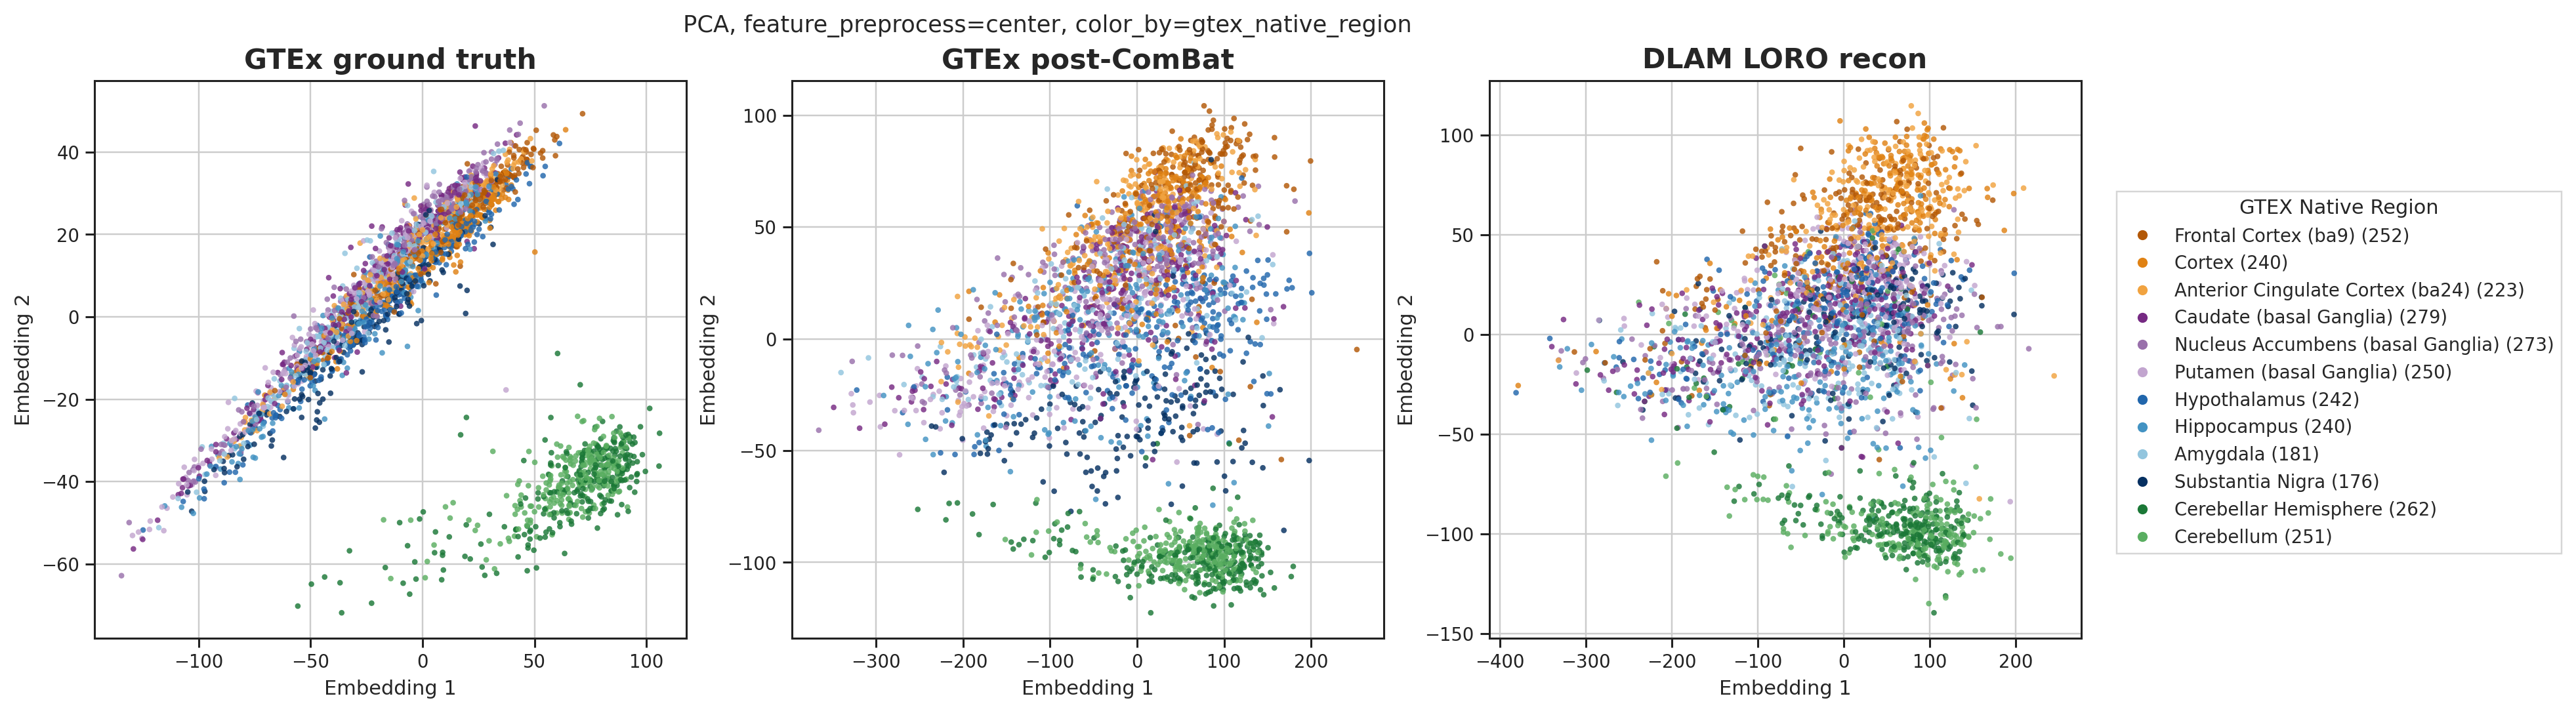

[{'explained_variance_ratio': [0.49470325615319277, 0.16473809252538962],
  'n_components': 2,
  'preprocess_zero_scale_features': 0},
 {'explained_variance_ratio': [0.4035802975991371, 0.14439239889867708],
  'n_components': 2,
  'preprocess_zero_scale_features': 0},
 {'explained_variance_ratio': [0.494581244071421, 0.15208578326443428],
  'n_components': 2,
  'preprocess_zero_scale_features': 0}]

In [15]:
pca_embeddings = [
    compute_pca_embedding(
        mat,
        n_components=2,
        feature_preprocess=FEATURE_PREPROCESS,
        random_state=RANDOM_STATE,
    )
    for mat in MATRICES
]

fig, axes = plot_embedding_sequence(
    pca_embeddings,
    color_by=COLOR_BY,
    titles=STAGE_TITLES,
    max_legend_items=MAX_LEGEND_ITEMS,
    point_size=POINT_SIZE,
)
fig.suptitle(f"PCA, feature_preprocess={FEATURE_PREPROCESS}, color_by={COLOR_BY}", y=1.04)
plt.show()

[emb.fit_info for emb in pca_embeddings]


## UMAP

In [16]:
# UMAP layout knobs — raise min_dist / spread / repulsion to encourage cluster
# spread + separation (closer to the reference sample_umap layout).
UMAP_N_NEIGHBORS = 15        # lower (~10) = more local detail; higher = more global blob
UMAP_MIN_DIST = 0.5          # up from 0.1 -> points spread out instead of clumping
UMAP_SPREAD = 1.5            # global scale of the embedding (min_dist <= spread)
UMAP_REPULSION = 1.5         # repulsion_strength: >1 pushes clusters apart
UMAP_METRIC = 'cosine'    # 'cosine' often separates expression profiles better


/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


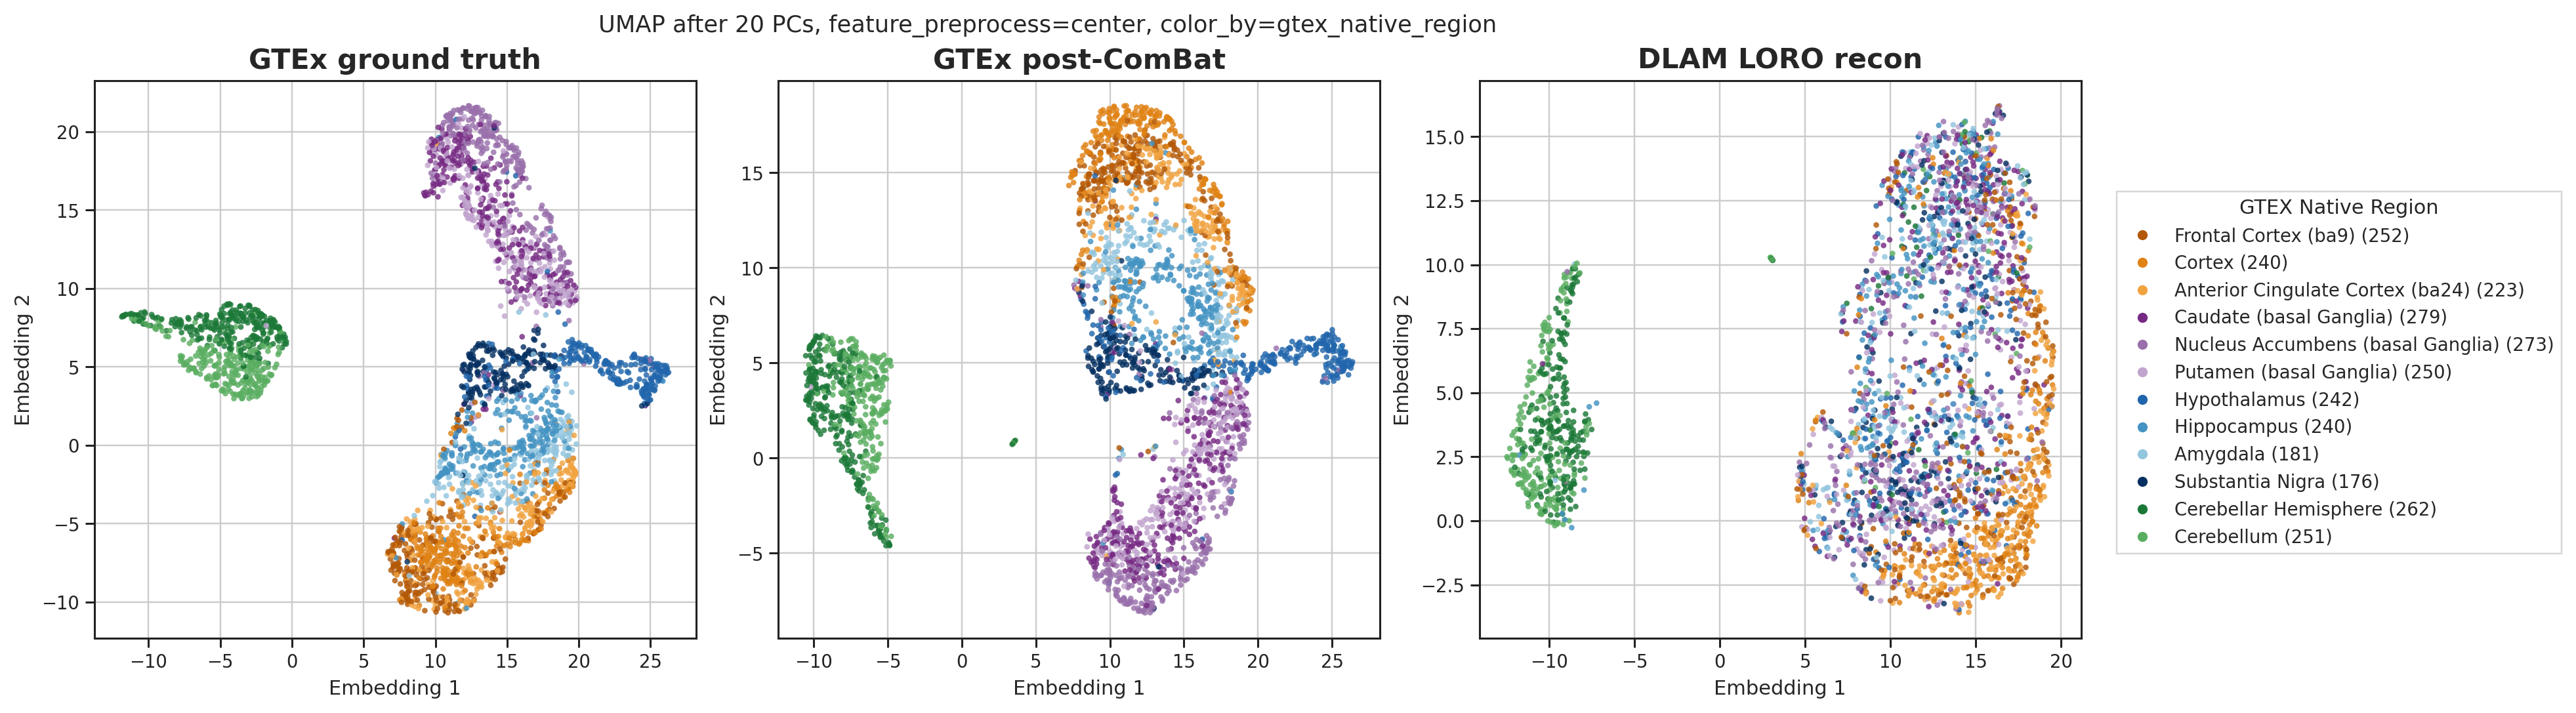

[{'n_pca': 20,
  'n_neighbors': 15,
  'min_dist': 0.5,
  'metric': 'cosine',
  'random_state': 0,
  'preprocess_zero_scale_features': 0},
 {'n_pca': 20,
  'n_neighbors': 15,
  'min_dist': 0.5,
  'metric': 'cosine',
  'random_state': 0,
  'preprocess_zero_scale_features': 0},
 {'n_pca': 20,
  'n_neighbors': 15,
  'min_dist': 0.5,
  'metric': 'cosine',
  'random_state': 0,
  'preprocess_zero_scale_features': 0}]

In [17]:
umap_embeddings = [
    compute_umap_embedding(
        mat,
        n_pca=N_PCA_FOR_UMAP,
        feature_preprocess=FEATURE_PREPROCESS,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=RANDOM_STATE,
        umap_kwargs={'spread': UMAP_SPREAD, 'repulsion_strength': UMAP_REPULSION},
    )
    for mat in MATRICES
]

fig, axes = plot_embedding_sequence(
    umap_embeddings,
    color_by=COLOR_BY,
    titles=STAGE_TITLES,
    max_legend_items=MAX_LEGEND_ITEMS,
    point_size=POINT_SIZE,
)
fig.suptitle(f"UMAP after {umap_embeddings[0].fit_info['n_pca']} PCs, feature_preprocess={FEATURE_PREPROCESS}, color_by={COLOR_BY}", y=1.04)
plt.show()

[emb.fit_info for emb in umap_embeddings]


## Coloring Controls

Region-wise panels are colored by `COLOR_BY` (set in the config cell). The default `"gtex_native_region"` colors samples by native GTEx tissue name; `"region"` uses AHBA target parcels. `"age"`, `"sex"`, and `"dataset"` use sample metadata (age is shown with a continuous colorbar); `"macro_system"` and `"region_group"` switch to broader anatomical labels. Region palettes are shared through `eval_style`, matching the region-stratified population plots.


## Gene-Wise Embeddings

Transpose each stage to **gene rows x subject-region-sample features** via `build_gene_embedding_matrix`. Per-gene color attributes are computed once from the ground-truth (raw_matched) matrix and reused across all three panels, so a gene keeps the same color pre / post / LORO recon.

Gene color options: `peak_region` | `peak_region_group` | `gene_mean` | `gene_cv`.

In [18]:
# peak_region | peak_region_group | gene_mean | gene_cv
GENE_COLOR_BY = 'gene_mean'
# Peak over native GTEx tissue (~11, clean legend matching the region-wise view)
# rather than the ~150 target parcels. Use 'region' for parcel-level peaks.
GENE_PEAK_OVER = 'gtex_native_region'

# Many more points than the region view -> small, highly-transparent markers so
# dense overlap reads as density instead of a solid blob.
GENE_POINT_SIZE = 4
GENE_ALPHA = 0.4

# Gene-wise UMAP knobs, tuned to encourage discrete group-wise clustering
# (vs. the region-wise knobs above, which favor spread). Tight min_dist packs
# within-cluster points; low n_neighbors emphasizes local structure; strong
# repulsion + unit spread pushes distinct gene groups apart.
GENE_UMAP_N_NEIGHBORS = 200
GENE_UMAP_MIN_DIST = 0.0
GENE_UMAP_SPREAD = 1.0
GENE_UMAP_REPULSION = 2.0
GENE_UMAP_METRIC = 'cosine'    # 'cosine' often separates expression profiles better

# Always use GENE_ counterparts for gene-wise settings below:
GENE_N_PCA_FOR_UMAP = 100
GENE_FEATURE_PREPROCESS = FEATURE_PREPROCESS
GENE_RANDOM_STATE = RANDOM_STATE
GENE_STAGE_TITLES = STAGE_TITLES
GENE_MAX_LEGEND_ITEMS = MAX_LEGEND_ITEMS

gene_matrices = [
    build_gene_embedding_matrix(mat, attribute_matrix=ground_truth_matrix, peak_over=GENE_PEAK_OVER)
    for mat in MATRICES
]
for title, gmat in zip(STAGE_TITLES, gene_matrices):
    print(f'{title}: {gmat.X.shape[0]:,} genes x {gmat.X.shape[1]:,} sample-features; row_axis={gmat.row_axis}')
gene_matrices[0].metadata.head()


GTEx ground truth: 11,704 genes x 2,869 sample-features; row_axis=gene
GTEx post-ComBat: 11,704 genes x 2,869 sample-features; row_axis=gene
DLAM LORO recon: 11,704 genes x 2,869 sample-features; row_axis=gene


,gene,dataset,stage,pipeline_stage,peak_region,peak_region_group,gene_mean,gene_cv
0,A1BG,GTEx,raw_matched,raw_matched,brain - cerebellar hemisphere,cerebellar,1.746960,0.243784
1,A1BG-AS1,GTEx,raw_matched,raw_matched,brain - cerebellum,cerebellar,1.058328,0.518641
2,AAAS,GTEx,raw_matched,raw_matched,brain - cerebellum,cerebellar,3.078698,0.176496
3,AACS,GTEx,raw_matched,raw_matched,brain - frontal cortex (ba9),cortical,2.424656,0.292575
4,AADAT,GTEx,raw_matched,raw_matched,brain - frontal cortex (ba9),cortical,1.906287,0.323670


### Gene-wise PCA

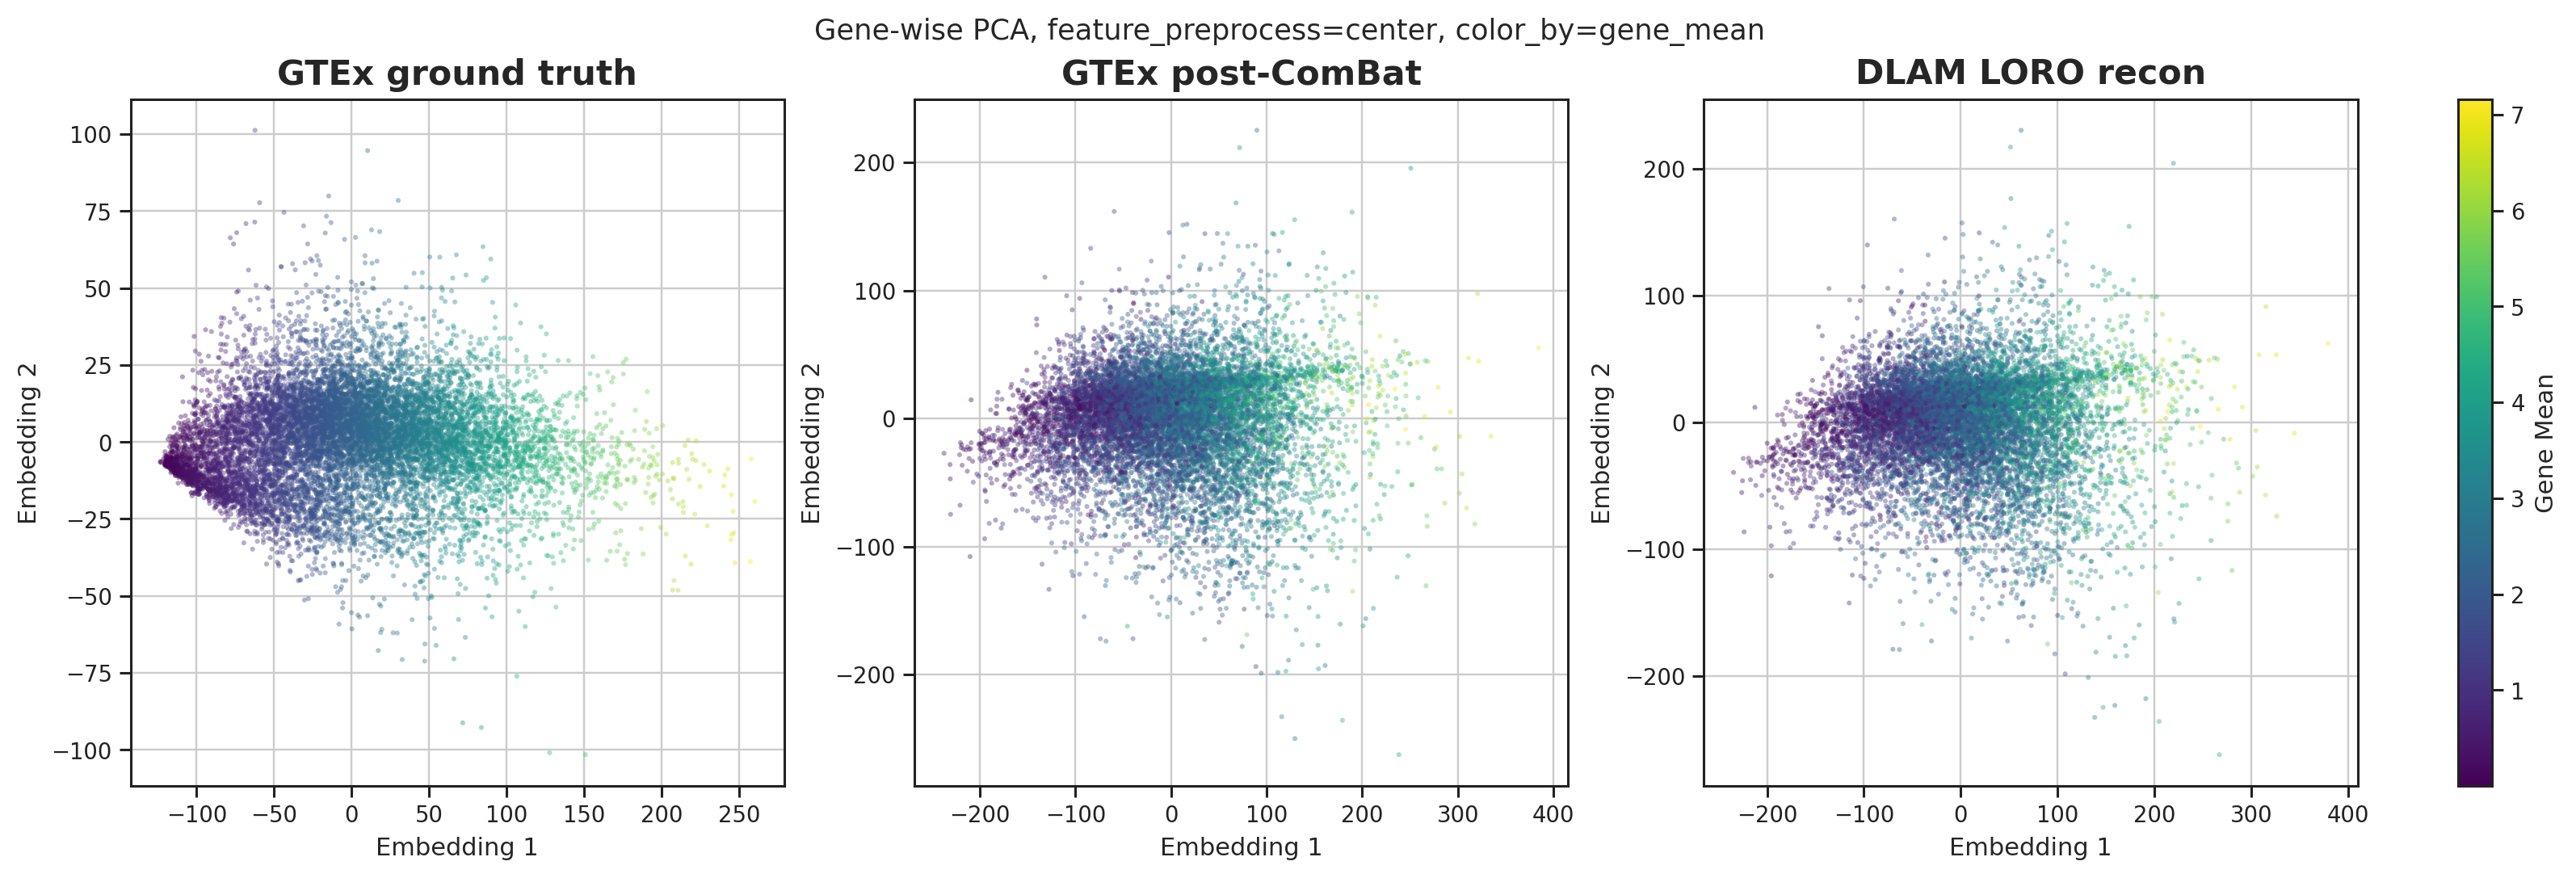

[{'explained_variance_ratio': [0.8587756807905695, 0.05726363330244082],
  'n_components': 2,
  'preprocess_zero_scale_features': 0},
 {'explained_variance_ratio': [0.56027115293092, 0.1474590054136541],
  'n_components': 2,
  'preprocess_zero_scale_features': 0},
 {'explained_variance_ratio': [0.6068419583621317, 0.16483025752986374],
  'n_components': 2,
  'preprocess_zero_scale_features': 0}]

In [19]:
gene_pca = [
    compute_pca_embedding(gmat, n_components=2, feature_preprocess=FEATURE_PREPROCESS, random_state=RANDOM_STATE)
    for gmat in gene_matrices
]
fig, axes = plot_embedding_sequence(
    gene_pca, color_by=GENE_COLOR_BY, titles=STAGE_TITLES,
    max_legend_items=MAX_LEGEND_ITEMS, point_size=GENE_POINT_SIZE, alpha=GENE_ALPHA,
)
fig.suptitle(f'Gene-wise PCA, feature_preprocess={FEATURE_PREPROCESS}, color_by={GENE_COLOR_BY}', y=1.04)
plt.show()
[emb.fit_info for emb in gene_pca]


### Gene-wise UMAP

/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


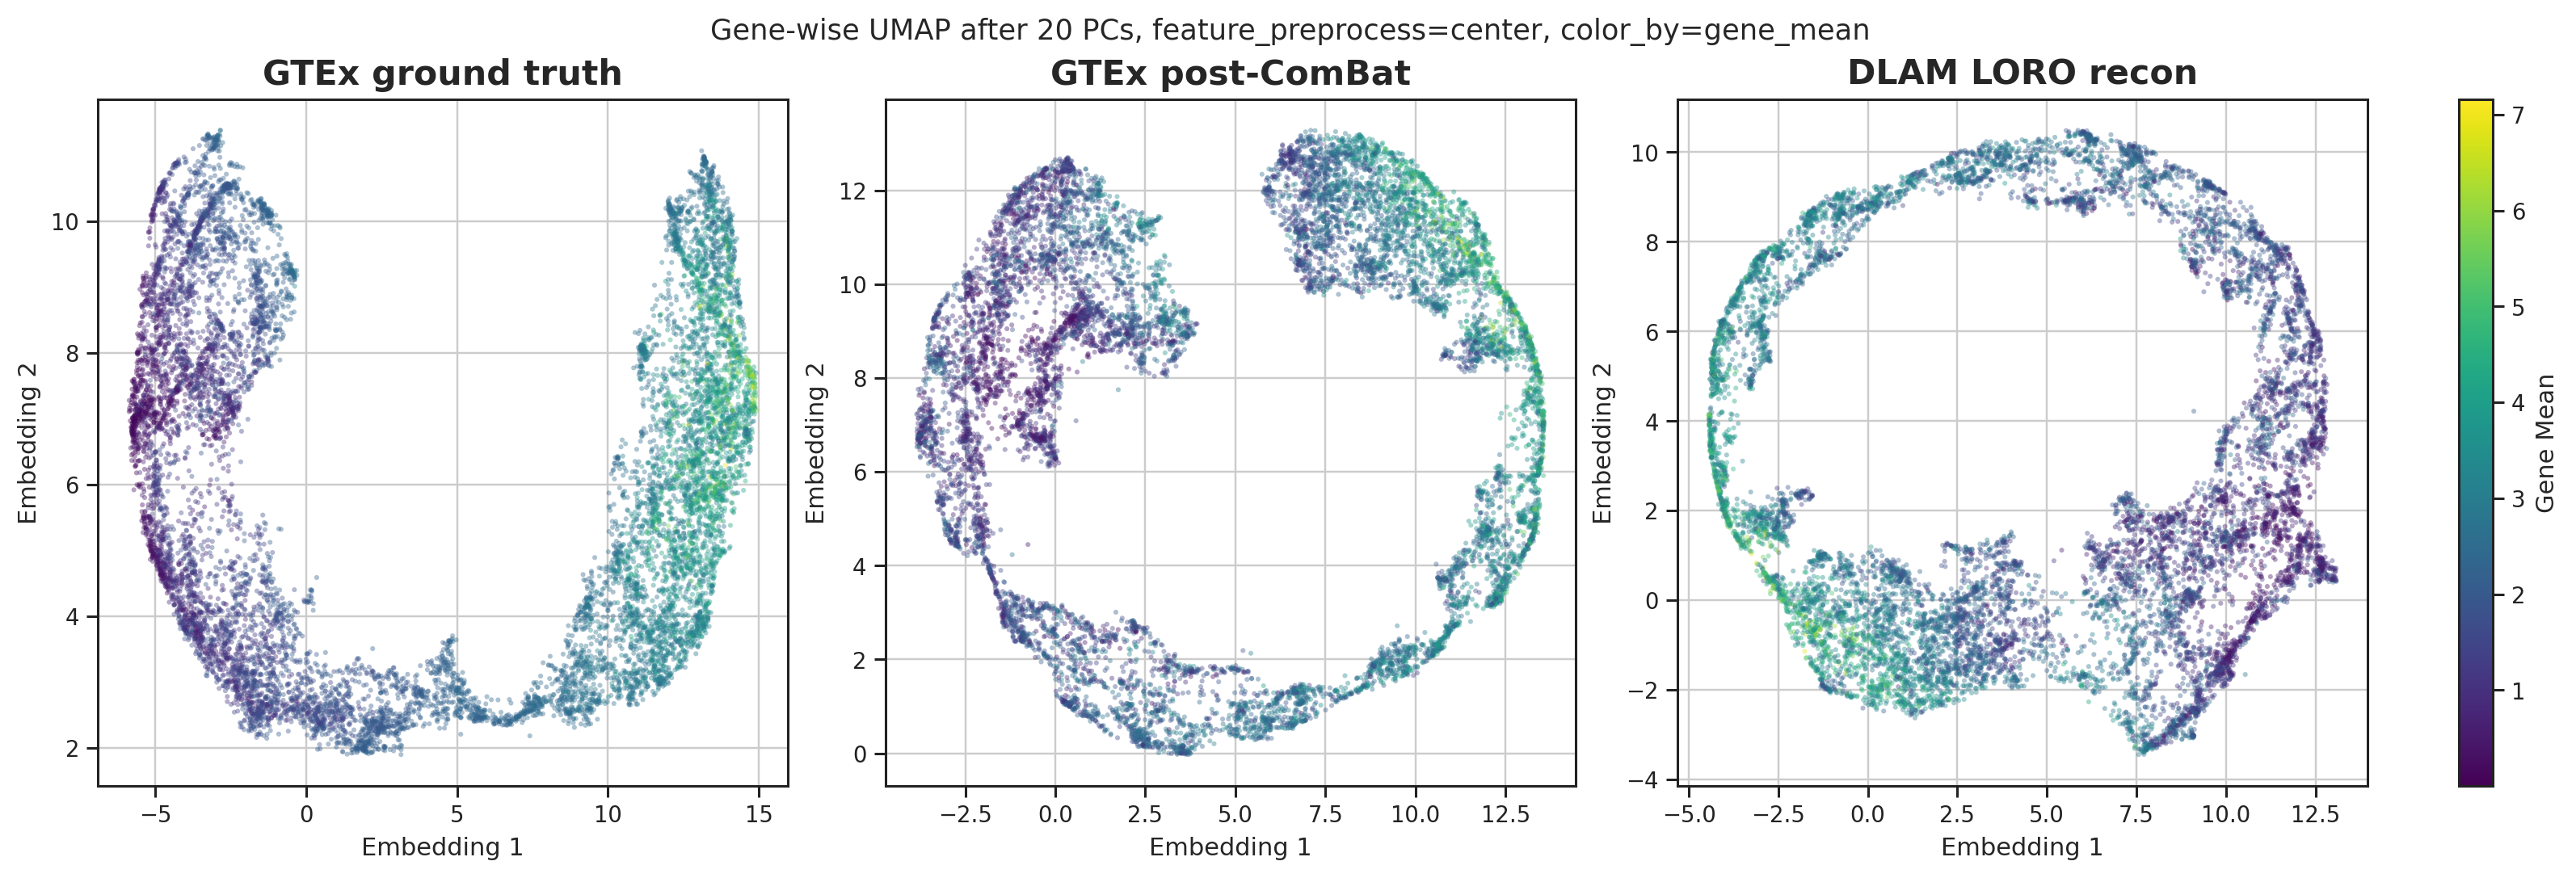

[{'n_pca': 20,
  'n_neighbors': 200,
  'min_dist': 0.0,
  'metric': 'cosine',
  'random_state': 0,
  'preprocess_zero_scale_features': 0},
 {'n_pca': 20,
  'n_neighbors': 200,
  'min_dist': 0.0,
  'metric': 'cosine',
  'random_state': 0,
  'preprocess_zero_scale_features': 0},
 {'n_pca': 20,
  'n_neighbors': 200,
  'min_dist': 0.0,
  'metric': 'cosine',
  'random_state': 0,
  'preprocess_zero_scale_features': 0}]

In [20]:
gene_umap = [
    compute_umap_embedding(
        gmat,
        n_pca=N_PCA_FOR_UMAP,
        feature_preprocess=FEATURE_PREPROCESS,
        n_neighbors=GENE_UMAP_N_NEIGHBORS,
        min_dist=GENE_UMAP_MIN_DIST,
        metric=GENE_UMAP_METRIC,
        random_state=RANDOM_STATE,
        umap_kwargs={'spread': GENE_UMAP_SPREAD, 'repulsion_strength': GENE_UMAP_REPULSION},
    )
    for gmat in gene_matrices
]
fig, axes = plot_embedding_sequence(
    gene_umap, color_by=GENE_COLOR_BY, titles=STAGE_TITLES,
    max_legend_items=MAX_LEGEND_ITEMS, point_size=GENE_POINT_SIZE, alpha=GENE_ALPHA,
)
fig.suptitle(f"Gene-wise UMAP after {gene_umap[0].fit_info['n_pca']} PCs, feature_preprocess={FEATURE_PREPROCESS}, color_by={GENE_COLOR_BY}", y=1.04)
plt.show()
[emb.fit_info for emb in gene_umap]
